In [1]:
import scipy as sp
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Latex
import pandas as pd

In [2]:
def ecxxmaker(t0, theta, mode, window, showpoints):
    def ec22(fplus, fminus):
      iksi = (abs(fplus - fminus))/(fplus + fminus)
      psi = (1/3)*np.arctan2(np.sqrt(1-iksi**2), iksi)
      e_c = np.cos(psi) - np.sqrt(3)*np.sin(psi)
      return e_c

    def ec33(fplus, fminus):
      iksi = (abs(fplus - fminus))/(fplus + fminus)
      theta = (1/3)*np.arctan((1242*np.sqrt(3)/iksi)*(np.sqrt(35266176 - 31184003*iksi**2 - 3675129*iksi**4)/(15712542 + 1225043*iksi**2)))
      return (1/138)*(-107*iksi + np.sqrt(54648 + 11449*iksi)*np.cos(theta)-np.sqrt(163944 + 34347*iksi)*np.sin(theta))

    def ec44func(e):
      return (2*e*(6944-5700*e**2+261*e**4))/(8192-1513*e**2-3669*e**4)

    dt = abs(t0[1] - t0[0])
    #dtheta_dt = -sp.signal.savgol_filter(theta, window_length=100, polyorder=5, deriv=1, delta=dt)
    dtheta_dt = -np.gradient(theta, t0)
    dtheta_dt = sp.signal.savgol_filter(dtheta_dt, window_length=window, polyorder=3, delta=dt)
    fvalues = dtheta_dt / (2 * np.pi)
    #dfvalues = sp.signal.savgol_filter(fvalues, window_length=175, polyorder=3, deriv=1, delta=dt)
    dfvalues = np.gradient(fvalues, t0)
    dfvalues = sp.signal.savgol_filter(dfvalues, window_length=window, polyorder=3, delta=dt)
    zero_crossings = np.where(dfvalues[1:] * dfvalues[:-1] < 0)[0]
    zero_crossings2 = np.roll(zero_crossings, shift=1)
    zero_crossings3 = np.average(np.array([zero_crossings, zero_crossings2]), axis=0).astype(int)
    fplus = fvalues[zero_crossings]
    fminus = fvalues[zero_crossings2]
    iksi = (abs(fplus - fminus))/(fplus + fminus)
    if mode == 22:
      ee = ec22(fplus, fminus)
    elif mode == 33:
      ee = ec33(fplus, fminus)
    elif mode == 44:
      def ec44(e, iksi):
          return ec44func(e) - iksi
      ee = np.array([sp.optimize.root_scalar(ec44, args=(j,), x0=0.2, xtol = 1e-10).root for j in iksi])
    else: return 0

    timec = t0[zero_crossings3]
    ec_top = ee[1:-1:2]
    ec_bot = ee[2::2]
    timec_top = timec[1:-1:2]
    timec_bot = timec[2::2]
    ec_ave = np.average(np.array([ec_top, ec_bot]), axis =0)
    time_ave = np.average(np.array([timec_top, timec_bot]), axis =0)
    if showpoints: return timec_top, timec_bot, ec_top, ec_bot, time_ave, ec_ave
    else: return time_ave, ec_ave

def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx

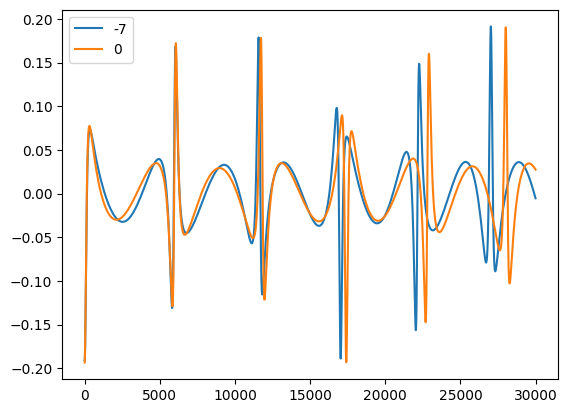

In [3]:
hpsds = pd.read_csv(r'CSV\plus_50_7_-7.csv', header=None, names=['t0', 'h+'])
hcsds = pd.read_csv(r'CSV\cross_50_7_-7.csv', header=None, names=['t0', 'h+'])
hpsds0 = pd.read_csv(r'CSV\plus_50_7_0.csv', header=None, names=['t0', 'h+'])
hcsds0 = pd.read_csv(r'CSV\cross_50_7_0.csv', header=None, names=['t0', 'h+'])
tp = hpsds['t0']
tc = hcsds['t0']
hpsd = hpsds['h+']
hcsd = hcsds['h+']
tp0 = hpsds0['t0']
tc0 = hcsds0['t0']
hpsd0 = hpsds0['h+']
hcsd0 = hcsds0['h+']
plt.plot(tp, hpsd, label="-7")
plt.plot(tp0, hpsd0, label="0")
plt.legend()


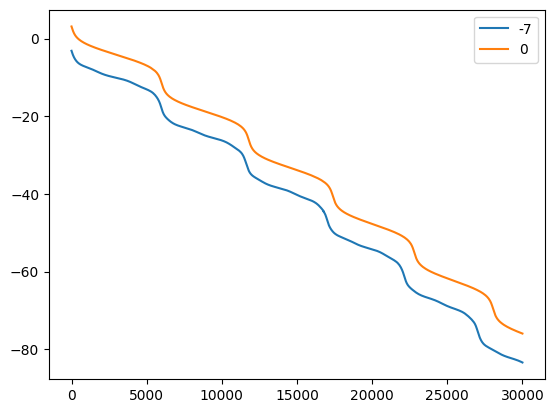

In [4]:

#Arrays are not of the same size, might be best to interpolate now.
t10k = np.linspace(0, np.max(tp), 5000)
cplus = sp.interpolate.CubicSpline(tp, hpsd)
ccross = sp.interpolate.CubicSpline(tc, hcsd)
hp_int = cplus(t10k)
hc_int = ccross(t10k)
thetasds = np.unwrap(np.arctan2(-hc_int, hp_int))
t100k = np.linspace(0, np.max(tp0), 5000)
cplus0 = sp.interpolate.CubicSpline(tp0, hpsd0)
ccross0 = sp.interpolate.CubicSpline(tc0, hcsd0)
hp_int0 = cplus0(t100k)
hc_int0 = ccross0(t100k)
thetasds0 = np.unwrap(np.arctan2(-hc_int0, hp_int0))

# ddt = np.gradient(thetasds, t10k)
# ddt0 = np.gradient(thetasds0, t100k)
# ddt = sp.signal.savgol_filter(ddt, window_length=500, polyorder=3, delta=t10k[1]-t10k[0])
# ddt0 = sp.signal.savgol_filter(ddt0, window_length=500, polyorder=3, delta=t100k[1]-t100k[0])

plt.plot(t10k, thetasds, label="-7")
plt.plot(t100k, thetasds0, label="0")
plt.legend()


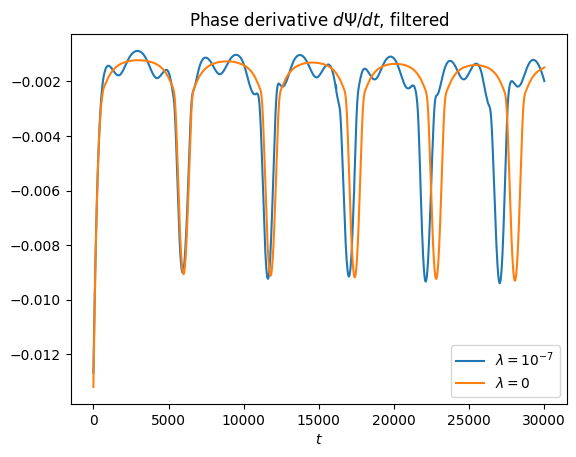

In [5]:
ddt = np.gradient(thetasds, t10k)
ddt0 = np.gradient(thetasds0, t100k)
ddt = sp.signal.savgol_filter(ddt, window_length=200, polyorder=3, delta=t10k[1]-t10k[0])
ddt0 = sp.signal.savgol_filter(ddt0, window_length=200, polyorder=3, delta=t100k[1]-t100k[0])
plt.plot(t10k, ddt, label=r"$\lambda=10^{-7}$")
plt.plot(t100k, ddt0, label=r"$\lambda=0$")
plt.title(r"Phase derivative $d\Psi / dt$, filtered")
plt.xlabel(r"$t$")
plt.legend()

In [6]:

#Arrays are not of the same size, might be best to interpolate now.
t100k = np.linspace(0, np.max(tp0), 10000)
cplus0 = sp.interpolate.CubicSpline(tp0, hpsd0)
ccross0 = sp.interpolate.CubicSpline(tc0, hcsd0)
hp_int0 = cplus0(t100k)
hc_int0 = ccross0(t100k)
thetasds0 = np.unwrap(np.arctan2(-hc_int0, hp_int0))
t_c, e_c = ecxxmaker(t10k, thetasds, 22, 200, False)
t_c = np.delete(t_c, 1)
e_c = np.delete(e_c, 1)
t_c0, e_c0 = ecxxmaker(t100k, thetasds0, 22, 100, False)
t_c0 = np.delete(t_c0, 1)
e_c0 = np.delete(e_c0, 1)

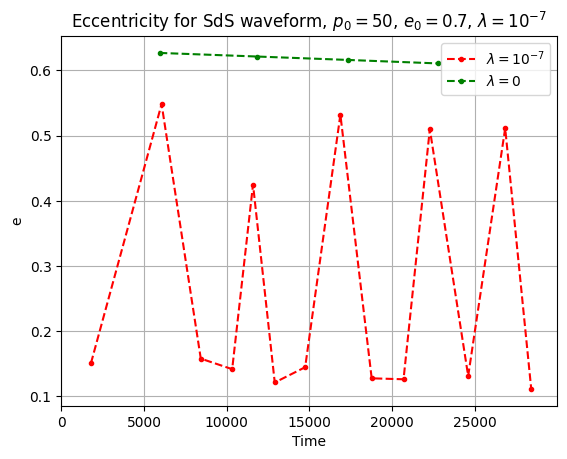

In [7]:
plt.plot(t_c, e_c, 'r--.', label=r"$\lambda=10^{-7}$")
plt.plot(t_c0, e_c0, 'g--.', label=r'$\lambda=0$')
plt.title(r"Eccentricity for SdS waveform, $p_0 = 50$, $e_0 = 0.7$, $\lambda = 10^{-7}$")
plt.legend()
plt.xlim(0, np.max(t10k))
# plt.ylim(0.6, 0.64)
plt.xlabel('Time')
plt.ylabel(r"e")
plt.grid(True)

In [8]:
#Loading all the CSV files from the CSV folder.
hpsds05 = pd.read_csv(r'CSV\plus_50_05_0_10k.csv', header=None, names=['t0', 'h+'])
hcsds05 = pd.read_csv(r'CSV\cross_50_05_0_10k.csv', header=None, names=['t0', 'h+'])
hpsds1 = pd.read_csv(r'CSV\plus_50_1_0_10k.csv', header=None, names=['t0', 'h+'])
hcsds1 = pd.read_csv(r'CSV\cross_50_1_0_10k.csv', header=None, names=['t0', 'h+'])
hpsds2 = pd.read_csv(r'CSV\plus_50_2_0_10k.csv', header=None, names=['t0', 'h+'])
hcsds2 = pd.read_csv(r'CSV\cross_50_2_0_10k.csv', header=None, names=['t0', 'h+'])
hpsds3 = pd.read_csv(r'CSV\plus_50_3_0_10k.csv', header=None, names=['t0', 'h+'])
hcsds3 = pd.read_csv(r'CSV\cross_50_3_0_10k.csv', header=None, names=['t0', 'h+'])
hpsds4 = pd.read_csv(r'CSV\plus_50_4_0_10k.csv', header=None, names=['t0', 'h+'])
hcsds4 = pd.read_csv(r'CSV\cross_50_4_0_10k.csv', header=None, names=['t0', 'h+'])
hpsds5 = pd.read_csv(r'CSV\plus_50_5_0_10k.csv', header=None, names=['t0', 'h+'])
hcsds5 = pd.read_csv(r'CSV\cross_50_5_0_10k.csv', header=None, names=['t0', 'h+'])
hpsds6 = pd.read_csv(r'CSV\plus_50_6_0_10k.csv', header=None, names=['t0', 'h+'])
hcsds6 = pd.read_csv(r'CSV\cross_50_6_0_10k.csv', header=None, names=['t0', 'h+'])
hpsds7 = pd.read_csv(r'CSV\plus_50_7_0_10k.csv', header=None, names=['t0', 'h+'])
hcsds7 = pd.read_csv(r'CSV\cross_50_7_0_10k.csv', header=None, names=['t0', 'h+'])
hpsds8 = pd.read_csv(r'CSV\plus_50_8_0_10k.csv', header=None, names=['t0', 'h+'])
hcsds8 = pd.read_csv(r'CSV\cross_50_8_0_10k.csv', header=None, names=['t0', 'h+'])
hpsds9 = pd.read_csv(r'CSV\plus_50_9_0_10k.csv', header=None, names=['t0', 'h+'])
hcsds9 = pd.read_csv(r'CSV\cross_50_9_0_10k.csv', header=None, names=['t0', 'h+'])
tp05 = hpsds05['t0']
tc05 = hcsds05['t0']
hpsd05 = hpsds05['h+']
hcsd05 = hcsds05['h+']
tp1 = hpsds1['t0']
tc1 = hcsds1['t0']
hpsd1 = hpsds1['h+']
hcsd1 = hcsds1['h+']
tp2 = hpsds2['t0']
tc2 = hcsds2['t0']
hpsd2 = hpsds2['h+']
hcsd2 = hcsds2['h+']
tp3 = hpsds3['t0']
tc3 = hcsds3['t0']
hpsd3 = hpsds3['h+']
hcsd3 = hcsds3['h+']
tp4 = hpsds4['t0']
tc4 = hcsds4['t0']
hpsd4 = hpsds4['h+']
hcsd4 = hcsds4['h+']
tp5 = hpsds5['t0']
tc5 = hcsds5['t0']
hpsd5 = hpsds5['h+']
hcsd5 = hcsds5['h+']
tp6 = hpsds6['t0']
tc6 = hcsds6['t0']
hpsd6 = hpsds6['h+']
hcsd6 = hcsds6['h+']
tp7 = hpsds7['t0']
tc7 = hcsds7['t0']
hpsd7 = hpsds7['h+']
hcsd7 = hcsds7['h+']
tp8 = hpsds8['t0']
tc8 = hcsds8['t0']
hpsd8 = hpsds8['h+']
hcsd8 = hcsds8['h+']
tp9 = hpsds9['t0']
tc9 = hcsds9['t0']
hpsd9 = hpsds9['h+']
hcsd9 = hcsds9['h+']

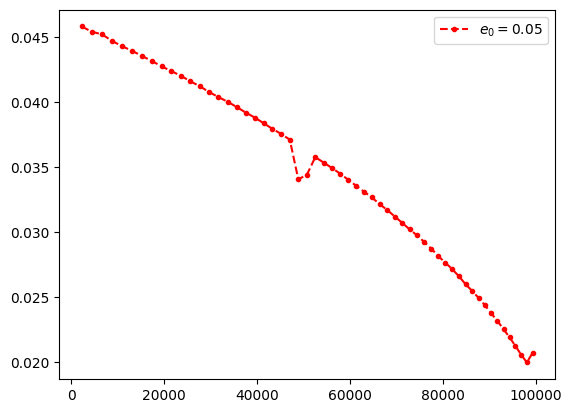

In [9]:
t05 = np.linspace(0, np.max(tp05), 5000)
cplus05 = sp.interpolate.CubicSpline(tp05, hpsd05)
ccross05 = sp.interpolate.CubicSpline(tc05, hcsd05)
hp_int05 = cplus05(t05)
hc_int05 = ccross05(t05)
thetasds05 = np.unwrap(np.arctan2(-hc_int05, hp_int05))
# ddt = np.gradient(thetasds1, t1)
# ddt = sp.signal.savgol_filter(ddt, window_length=400, polyorder=3, delta=t1[1]-t1[0])
# plt.plot(ddt)
t_c05, e_c05 = ecxxmaker(t05, thetasds05, 22, 55, False)
plt.plot(t_c05, e_c05, 'r--.', label=r"$e_0 = 0.05$")
plt.legend()

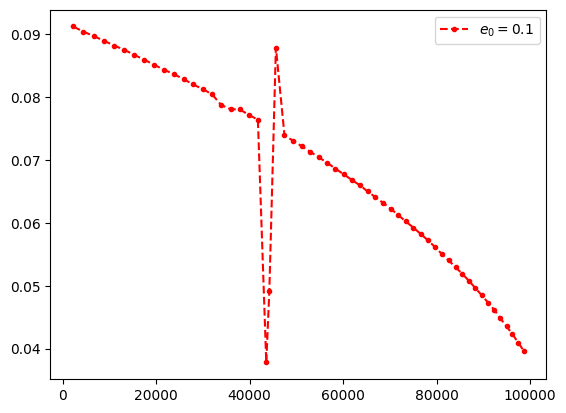

In [10]:
t1 = np.linspace(0, np.max(tp1), 5000)
cplus1 = sp.interpolate.CubicSpline(tp1, hpsd1)
ccross1 = sp.interpolate.CubicSpline(tc1, hcsd1)
hp_int1 = cplus1(t1)
hc_int1 = ccross1(t1)
thetasds1 = np.unwrap(np.arctan2(-hc_int1, hp_int1))
# ddt = np.gradient(thetasds1, t1)
# ddt = sp.signal.savgol_filter(ddt, window_length=400, polyorder=3, delta=t1[1]-t1[0])
# plt.plot(ddt)
t_c1, e_c1 = ecxxmaker(t1, thetasds1, 22, 55, False)
plt.plot(t_c1, e_c1, 'r--.', label=r"$e_0 = 0.1$")
plt.legend()

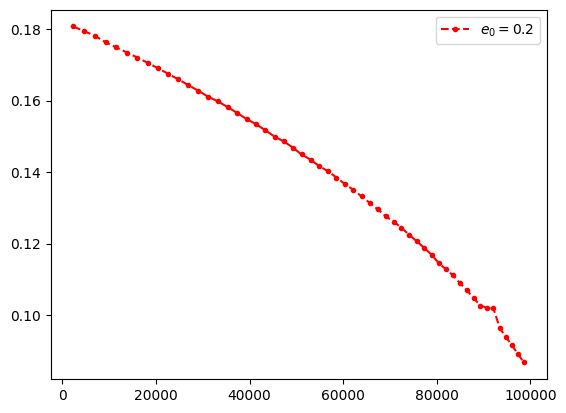

In [11]:
t2 = np.linspace(0, np.max(tp2), 5000)
cplus2 = sp.interpolate.CubicSpline(tp2, hpsd2)
ccross2 = sp.interpolate.CubicSpline(tc2, hcsd2)
hp_int2 = cplus2(t2)
hc_int2 = ccross2(t2)
thetasds2 = np.unwrap(np.arctan2(-hc_int2, hp_int2))
# ddt = np.gradient(thetasds1, t1)
# ddt = sp.signal.savgol_filter(ddt, window_length=400, polyorder=3, delta=t1[1]-t1[0])
# plt.plot(ddt)
t_c2, e_c2 = ecxxmaker(t2, thetasds2, 22, 50, False)
plt.plot(t_c2, e_c2, 'r--.', label=r"$e_0 = 0.2$")
plt.legend()

C:\Users\ASPIRE\AppData\Local\Temp\ipykernel_6264\4016233564.py:4: RuntimeWarning: invalid value encountered in sqrt
  psi = (1/3)*np.arctan2(np.sqrt(1-iksi**2), iksi)


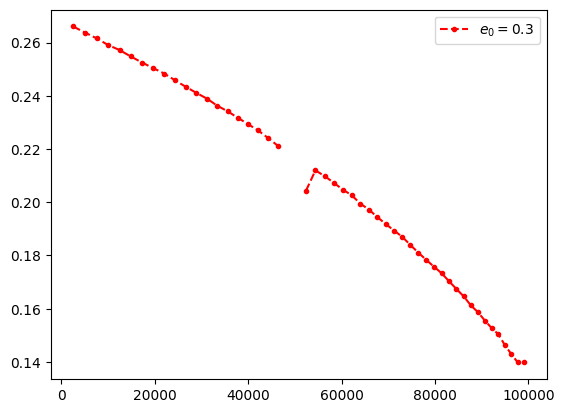

In [12]:
t3 = np.linspace(0, np.max(tp3), 5000)
cplus3 = sp.interpolate.CubicSpline(tp3, hpsd3)
ccross3 = sp.interpolate.CubicSpline(tc3, hcsd3)
hp_int3 = cplus3(t3)
hc_int3 = ccross3(t3)
thetasds3 = np.unwrap(np.arctan2(-hc_int3, hp_int3))
# ddt = np.gradient(thetasds1, t1)
# ddt = sp.signal.savgol_filter(ddt, window_length=400, polyorder=3, delta=t1[1]-t1[0])
# plt.plot(ddt)
t_c3, e_c3 = ecxxmaker(t3, thetasds3, 22, 50, False)
plt.plot(t_c3, e_c3, 'r--.', label=r"$e_0 = 0.3$")
plt.legend()

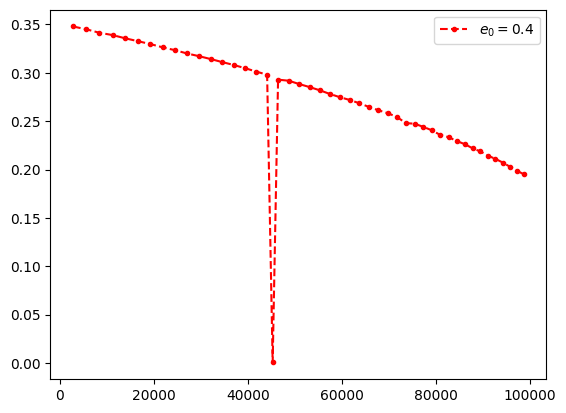

In [13]:
t4 = np.linspace(0, np.max(tp4), 5000)
cplus4 = sp.interpolate.CubicSpline(tp4, hpsd4)
ccross4 = sp.interpolate.CubicSpline(tc4, hcsd4)
hp_int4 = cplus4(t4)
hc_int4 = ccross4(t4)
thetasds4 = np.unwrap(np.arctan2(-hc_int4, hp_int4))
# ddt = np.gradient(thetasds1, t1)
# ddt = sp.signal.savgol_filter(ddt, window_length=400, polyorder=3, delta=t1[1]-t1[0])
# plt.plot(ddt)
t_c4, e_c4 = ecxxmaker(t4, thetasds4, 22, 50, False)
plt.plot(t_c4, e_c4, 'r--.', label=r"$e_0 = 0.4$")
plt.legend()

C:\Users\ASPIRE\AppData\Local\Temp\ipykernel_6264\4016233564.py:4: RuntimeWarning: invalid value encountered in sqrt
  psi = (1/3)*np.arctan2(np.sqrt(1-iksi**2), iksi)


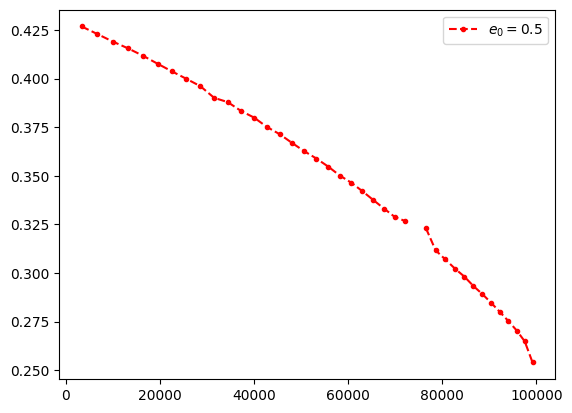

In [14]:
t5 = np.linspace(0, np.max(tp5), 5000)
cplus5 = sp.interpolate.CubicSpline(tp5, hpsd5)
ccross5 = sp.interpolate.CubicSpline(tc5, hcsd5)
hp_int5 = cplus5(t5)
hc_int5 = ccross5(t5)
thetasds5 = np.unwrap(np.arctan2(-hc_int5, hp_int5))
# ddt = np.gradient(thetasds1, t1)
# ddt = sp.signal.savgol_filter(ddt, window_length=400, polyorder=3, delta=t1[1]-t1[0])
# plt.plot(ddt)
t_c5, e_c5 = ecxxmaker(t5, thetasds5, 22, 50, False)
plt.plot(t_c5, e_c5, 'r--.', label=r"$e_0 = 0.5$")
plt.legend()

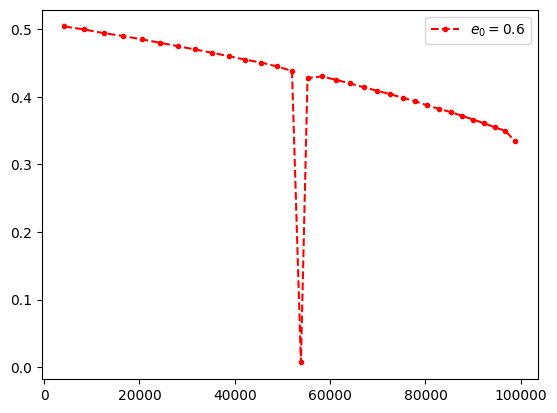

In [15]:
t6 = np.linspace(0, np.max(tp6), 5000)
cplus6 = sp.interpolate.CubicSpline(tp6, hpsd6)
ccross6 = sp.interpolate.CubicSpline(tc6, hcsd6)
hp_int6 = cplus6(t6)
hc_int6 = ccross6(t6)
thetasds6 = np.unwrap(np.arctan2(-hc_int6, hp_int6))
# ddt = np.gradient(thetasds1, t1)
# ddt = sp.signal.savgol_filter(ddt, window_length=400, polyorder=3, delta=t1[1]-t1[0])
# plt.plot(ddt)
t_c6, e_c6 = ecxxmaker(t6, thetasds6, 22, 50, False)
plt.plot(t_c6, e_c6, 'r--.', label=r"$e_0 = 0.6$")
plt.legend()

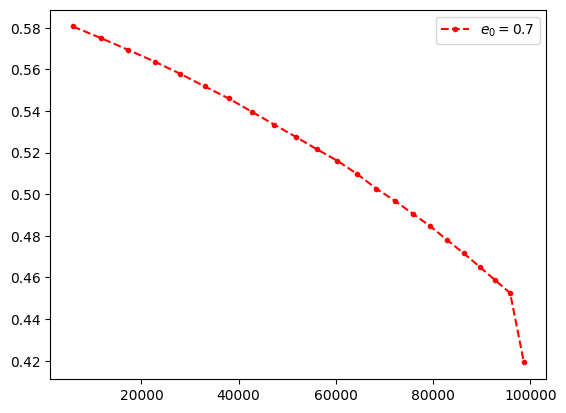

In [16]:
t7 = np.linspace(0, np.max(tp7), 5000)
cplus7 = sp.interpolate.CubicSpline(tp7, hpsd7)
ccross7 = sp.interpolate.CubicSpline(tc7, hcsd7)
hp_int7 = cplus7(t7)
hc_int7 = ccross7(t7)
thetasds7 = np.unwrap(np.arctan2(-hc_int7, hp_int7))
# ddt = np.gradient(thetasds1, t1)
# ddt = sp.signal.savgol_filter(ddt, window_length=400, polyorder=3, delta=t1[1]-t1[0])
# plt.plot(ddt)
t_c7, e_c7 = ecxxmaker(t7, thetasds7, 22, 50, False)
plt.plot(t_c7, e_c7, 'r--.', label=r"$e_0 = 0.7$")
plt.legend()

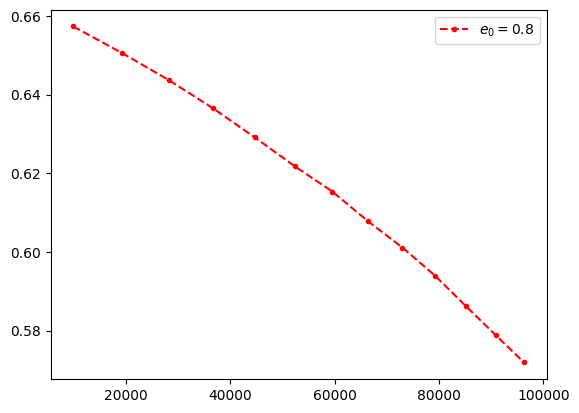

In [17]:
t8 = np.linspace(0, np.max(tp8), 5000)
cplus8 = sp.interpolate.CubicSpline(tp8, hpsd8)
ccross8 = sp.interpolate.CubicSpline(tc8, hcsd8)
hp_int8 = cplus8(t8)
hc_int8 = ccross8(t8)
thetasds8 = np.unwrap(np.arctan2(-hc_int8, hp_int8))
# ddt = np.gradient(thetasds1, t1)
# ddt = sp.signal.savgol_filter(ddt, window_length=400, polyorder=3, delta=t1[1]-t1[0])
# plt.plot(ddt)
t_c8, e_c8 = ecxxmaker(t8, thetasds8, 22, 50, False)
plt.plot(t_c8, e_c8, 'r--.', label=r"$e_0 = 0.8$")
plt.legend()

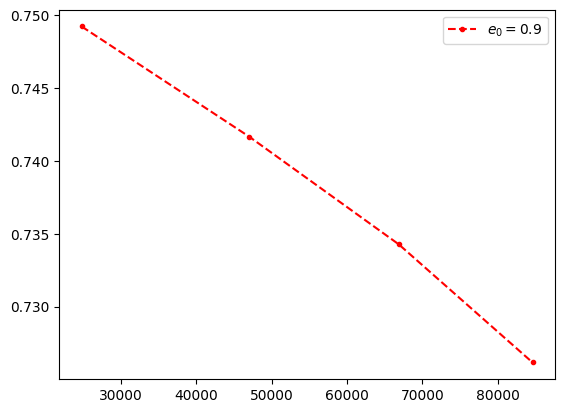

In [18]:
t9 = np.linspace(0, np.max(tp9), 5000)
cplus9 = sp.interpolate.CubicSpline(tp9, hpsd9)
ccross9 = sp.interpolate.CubicSpline(tc9, hcsd9)
hp_int9 = cplus9(t9)
hc_int9 = ccross9(t9)
thetasds9 = np.unwrap(np.arctan2(-hc_int9, hp_int9))
# ddt9 = np.gradient(thetasds9, t1)
# ddt9 = sp.signal.savgol_filter(ddt9, window_length=40, polyorder=3, delta=t9[1]-t9[0])
# plt.plot(ddt9)
t_c9, e_c9 = ecxxmaker(t9, thetasds9, 22, 39, False)
plt.plot(t_c9, e_c9, 'r--.', label=r"$e_0 = 0.9$")
plt.legend()

[ 2210.44204331  2240.44804389  2310.46204527  2510.50204919
  2830.56605546  3340.66806545  4240.84808309  5931.1861162
  9881.97619361 24764.95248519]


Text(0.5, 1.0, 'Difference between initialized $e_0$ and first $e_c$ measurement')

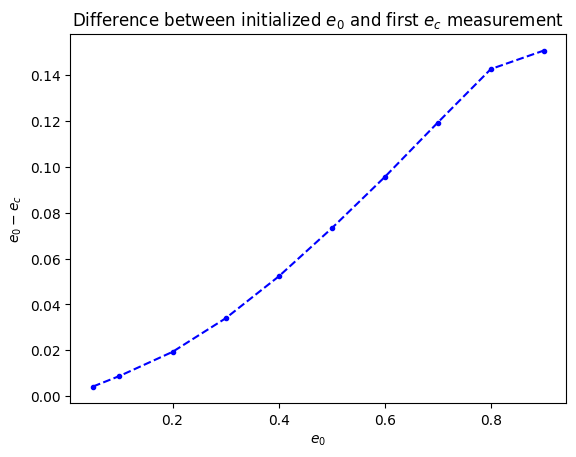

In [19]:
tccollect = np.array([t_c05[0], t_c1[0], t_c2[0], t_c3[0], t_c4[0], t_c5[0], t_c6[0], t_c7[0], t_c8[0], t_c9[0]])
eccollect = np.array([e_c05[0], e_c1[0], e_c2[0], e_c3[0], e_c4[0], e_c5[0], e_c6[0], e_c7[0], e_c8[0], e_c9[0]])
ec0coll = np.array([0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])
print(tccollect)
plt.plot(ec0coll, abs(ec0coll - eccollect), 'b--.')
plt.xlabel(r"$e_0$")
plt.ylabel(r"$e_0 - e_c$")
plt.title(r"Difference between initialized $e_0$ and first $e_c$ measurement")

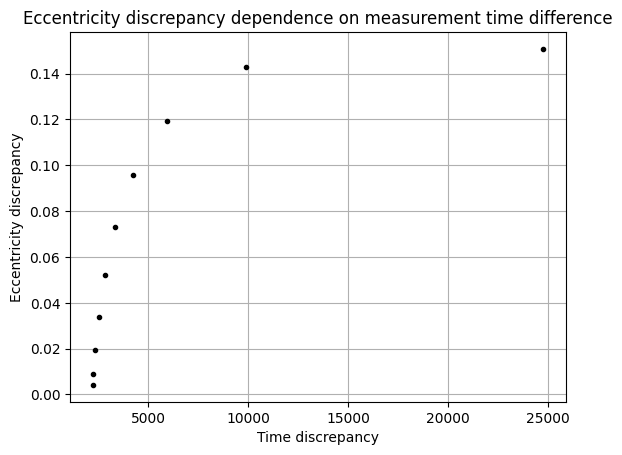

In [27]:
plt.plot(tccollect, abs(ec0coll-eccollect), 'k.')
# plt.yscale('log')
plt.title('Eccentricity discrepancy dependence on measurement time difference')
plt.xlabel('Time discrepancy')
plt.ylabel('Eccentricity discrepancy')
plt.grid(True)